INPUT WAVE GENERATION

Generating 2000 Gaussian-like pulses...


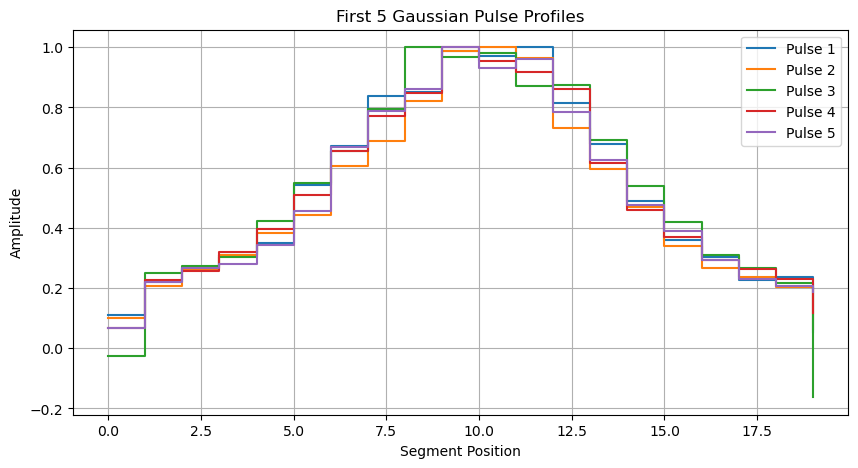

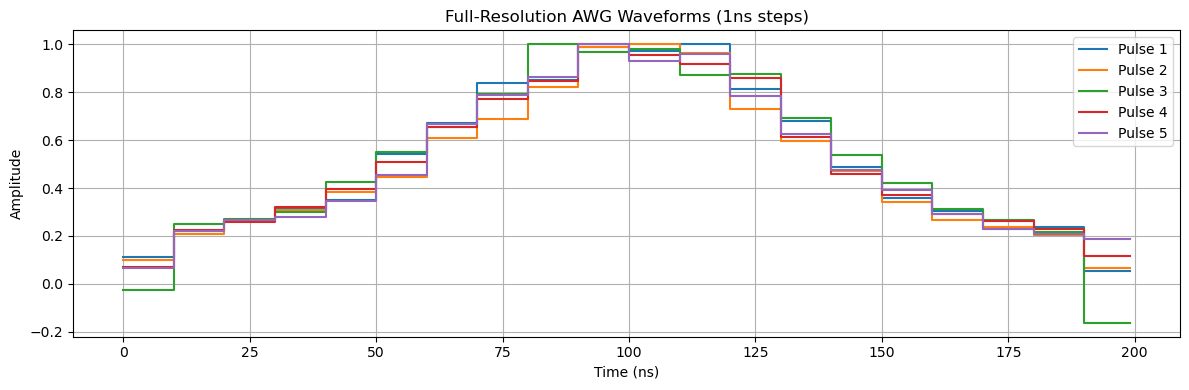

In [247]:
# pulse_generation_gaussian.py
import numpy as np
import matplotlib.pyplot as plt
import os

# ==================== PARAMETERS ====================
NUM_WAVEFORMS = 2000           # Total number of waveforms to generate
SEGMENTS = 20                 # Number of segments per waveform
SEGMENT_NS = 10               # Duration of each segment in nanoseconds
SAMPLE_RATE_HZ = 1e9          # AWG sampling rate (1 GHz = 1 ns resolution)
SEED = 42                     # Random seed for reproducibility
NUM_PLOTS = 5                 # Number of waveforms to visualize
CHUNK_SIZE = 200              # Max waveforms per file
SAVE_DIR = "waveform_chunks"
os.makedirs(SAVE_DIR, exist_ok=True)

# ==================== PULSE GENERATION ====================
rng = np.random.default_rng(SEED)

def generate_gaussian_pulse():
    x = np.linspace(-3, 3, SEGMENTS)
    gaussian = np.exp(-x**2 / 2)
    gaussian = 0.2 + (1. - 0.2) * gaussian
    pulse = np.zeros(SEGMENTS)
    for i in range(SEGMENTS):
        if i in [0, SEGMENTS - 1]:
            pulse[i] = rng.uniform(-0.2, 0.2)
        else:
            variation = 0.1 * gaussian[i]
            pulse[i] = rng.uniform(gaussian[i] - variation, gaussian[i] + variation)
    return pulse

amplitudes = np.array([generate_gaussian_pulse() for _ in range(NUM_WAVEFORMS)])
row_max = np.max(np.abs(amplitudes), axis=1, keepdims=True)
amplitudes = amplitudes / row_max

# ==================== VISUALIZATION ====================
def plot_pulses():
    plt.figure(figsize=(10, 5))
    for i in range(min(NUM_PLOTS, 5)):
        plt.step(np.arange(SEGMENTS), amplitudes[i], where='post', label=f'Pulse {i+1}')
    plt.xlabel('Segment Position')
    plt.ylabel('Amplitude')
    plt.title(f'First {min(NUM_PLOTS, 5)} Gaussian Pulse Profiles')
    plt.grid(True)
    plt.legend()
    plt.show()

    samples_per_segment = int(SEGMENT_NS * 1e-9 * SAMPLE_RATE_HZ)
    time_ns_full = np.arange(SEGMENTS * samples_per_segment) / SAMPLE_RATE_HZ * 1e9
    fig, ax = plt.subplots(figsize=(12, 4))
    for i in range(min(NUM_PLOTS, 5)):
        env = np.repeat(amplitudes[i], samples_per_segment)
        ax.step(time_ns_full, env, where='post', label=f'Pulse {i+1}')
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Amplitude')
    ax.set_title('Full-Resolution AWG Waveforms (1ns steps)')
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

# ==================== SAVE IN CHUNKS ====================
num_chunks = int(np.ceil(NUM_WAVEFORMS / CHUNK_SIZE))
for i in range(num_chunks):
    start = i * CHUNK_SIZE
    end = min((i + 1) * CHUNK_SIZE, NUM_WAVEFORMS)
    chunk = amplitudes[start:end]
    filename = f"waveforms_{start:03d}_{end-1:03d}.py"
    filepath = os.path.join(SAVE_DIR, filename)
    with open(filepath, "w") as f:
        f.write("waveforms = [\n")
        for pulse in chunk:
            values = ", ".join(f"{v:.6f}" for v in pulse)
            f.write(f"    [{values}],\n")
        f.write("]\n")

# ==================== MAIN ====================
if __name__ == "__main__":
    print(f"Generating {NUM_WAVEFORMS} Gaussian-like pulses...")
    plot_pulses()

OUTPUT PULSES EXTRACTION FROM .csv

✅ File loaded: 0-99_0.csv
🔢 Shape: (500002, 4)
📋 First 5 rows:
           0         1         2          3
0         X       CH3     Start  Increment
1  Sequence      VOLT  -3.00E-5   2.00E-10
2         0  -1.82E-1       NaN        NaN
3         1   0.00E+0       NaN        NaN
4         2   0.00E+0       NaN        NaN


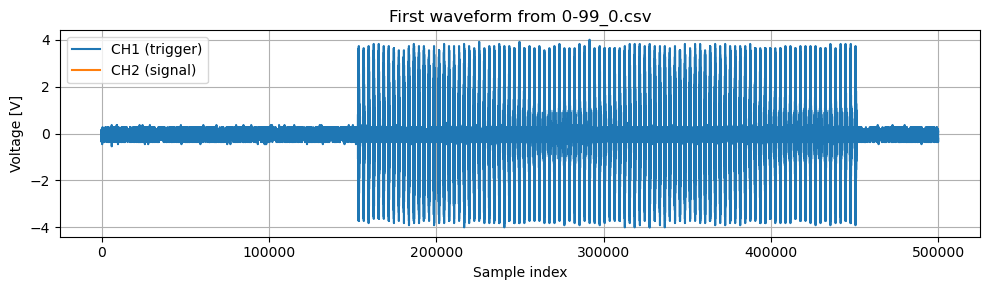

In [248]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
base = Path("2000 waveforms_output")

folder = Path("2000 waveforms_output/0-99")
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.CSV")))

# Select unique file
file = Path("2000 waveforms_output/0-99/0-99_0.csv")

# Read and show basic structure
raw = pd.read_csv(file, header=None, low_memory=False)
print("✅ File loaded:", file.name)
print("🔢 Shape:", raw.shape)
print("📋 First 5 rows:\n", raw.head())

# Extract CH1 and CH2 (after skipping 2 header rows)
ch1 = raw.iloc[2:, 1].astype(float).to_numpy()
ch2 = raw.iloc[2:, 2].astype(float).to_numpy()

# Plot both to inspect
plt.figure(figsize=(10, 3))
plt.plot(ch1, label="CH1 (trigger)")
plt.plot(ch2, label="CH2 (signal)")
plt.title("First waveform from 0-99_0.csv")
plt.xlabel("Sample index")
plt.ylabel("Voltage [V]")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()


📁 Found 10 trigger files


C:\Users\David\AppData\Local\Temp\ipykernel_22912\2230902147.py:15: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, header=None)
C:\Users\David\AppData\Local\Temp\ipykernel_22912\2230902147.py:15: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, header=None)
C:\Users\David\AppData\Local\Temp\ipykernel_22912\2230902147.py:15: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, header=None)
C:\Users\David\AppData\Local\Temp\ipykernel_22912\2230902147.py:15: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, header=None)
C:\Users\David\AppData\Local\Temp\ipykernel_22912\2230902147.py:15: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memo

✅ trigger_avg.shape = (500000,)


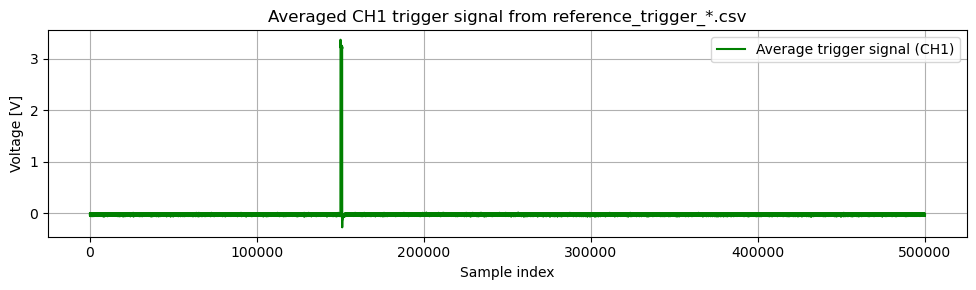

In [235]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --------- Load reference triggers from specific folder ---------
trigger_folder = Path("2000 waveforms_output")
ref_csvs = sorted(trigger_folder.glob("reference_trigger_*.csv"))
print(f"📁 Found {len(ref_csvs)} trigger files")

ref_signals = []

for f in ref_csvs:
    try:
        df = pd.read_csv(f, header=None)
        sig = df.iloc[2:, 1].astype(float).to_numpy()
        ref_signals.append(sig)
    except Exception as e:
        print(f"⚠️ Error reading {f.name}: {e}")

if not ref_signals:
    raise ValueError("❌ No trigger signals loaded. Check path or file content.")

# --------- Compute average trigger signal (CH1 global) ---------
trigger_avg = np.mean(np.vstack(ref_signals), axis=0)
print(f"✅ trigger_avg.shape = {trigger_avg.shape}")

# --------- Plot average trigger for verification ---------
plt.figure(figsize=(10, 3))
plt.plot(trigger_avg, label="Average trigger signal (CH1)", color='green')
plt.xlabel("Sample index")
plt.ylabel("Voltage [V]")
plt.title("Averaged CH1 trigger signal from reference_trigger_*.csv")
plt.grid(); plt.legend(); plt.tight_layout(); plt.show()


In [238]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------- Constants ----------
DT_NS           = 0.2
PERIOD_NS       = 600
PULSE_NS        = 200
POST_EDGE_NS    = 20
NUM_PULSES      = 100

SAMPLES_PER_PERIOD = int(PERIOD_NS / DT_NS)         # 3000
PULSE_SAMPLES      = int(PULSE_NS / DT_NS)          # 1000
POST_EDGE_SAMPLES  = int(POST_EDGE_NS / DT_NS)      # 165
WINDOW_SAMPLES     = 1400                           # directamente usado

# --------- Trigger: load and average the 10 reference triggers ----------
trigger_folder = Path("2000 waveforms_output")
ref_csvs = sorted(trigger_folder.glob("reference_trigger_*.csv"))

ref_signals = []
for f in ref_csvs:
    df = pd.read_csv(f, header=None)
    sig = df.iloc[2:, 1].astype(float).to_numpy()
    ref_signals.append(sig)

trigger_avg = np.mean(np.vstack(ref_signals), axis=0)
idx_trigger = np.argmax(trigger_avg > 0.5) + SAMPLES_PER_PERIOD

print(f"🟩 Using trigger index {idx_trigger} from averaged CH1")

# --------- Process all 20 folders ----------
base_folder = Path("2000 waveforms_output")
carpetas = sorted([d for d in base_folder.iterdir() if d.is_dir()],
                  key=lambda p: int(p.name.split("-")[0]))

windows_all = []

for folder in carpetas:
    print(f"📂 Processing folder: {folder.name}")
    
    acc = np.zeros((NUM_PULSES, WINDOW_SAMPLES), dtype=np.float64)
    files = sorted(folder.glob("*.csv"))
    files = [f for f in files if "reference_trigger" not in f.name]
    
    if len(files) != 10:
        raise ValueError(f"⚠️ Folder {folder.name} does not contain 10 valid CSVs (found {len(files)})")
    
    for f in files:
        raw = pd.read_csv(f, header=None, low_memory=False)
        ch2 = raw.iloc[2:, 1].astype(float).to_numpy()  # CH2 = signal

        for i in range(NUM_PULSES):
            start = idx_trigger + i * SAMPLES_PER_PERIOD
            end   = start + WINDOW_SAMPLES
            if end > len(ch2):
                raise ValueError(f"{f.name}: Not enough data at pulse {i}")
            acc[i] += ch2[start:end]
    
    windows_avg = acc / len(files)  # average over 10 files
    windows_all.append(windows_avg)

# --------- Stack all into final array (2000 pulses) ----------
windows = np.vstack(windows_all).astype(np.float32)
print("✅ Final windows.shape =", windows.shape)  # should be (2000, 1400)

C:\Users\David\AppData\Local\Temp\ipykernel_22912\3796834733.py:24: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, header=None)
C:\Users\David\AppData\Local\Temp\ipykernel_22912\3796834733.py:24: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, header=None)
C:\Users\David\AppData\Local\Temp\ipykernel_22912\3796834733.py:24: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, header=None)
C:\Users\David\AppData\Local\Temp\ipykernel_22912\3796834733.py:24: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, header=None)
C:\Users\David\AppData\Local\Temp\ipykernel_22912\3796834733.py:24: DtypeWarning: Columns (0,1,2,3) have mixed types. Specify dtype option on import or set low_memo

🟩 Using trigger index 152999 from averaged CH1
📂 Processing folder: 0-99
📂 Processing folder: 100-199
📂 Processing folder: 200-299
📂 Processing folder: 300-399
📂 Processing folder: 400-499
📂 Processing folder: 500-599
📂 Processing folder: 600-699
📂 Processing folder: 700-799
📂 Processing folder: 800-899
📂 Processing folder: 900-999
📂 Processing folder: 1000-1099
📂 Processing folder: 1100-1199
📂 Processing folder: 1200-1299
📂 Processing folder: 1300-1399
📂 Processing folder: 1400-1499
📂 Processing folder: 1500-1599
📂 Processing folder: 1600-1699
📂 Processing folder: 1700-1799
📂 Processing folder: 1800-1899
📂 Processing folder: 1900-1999
✅ Final windows.shape = (2000, 1400)


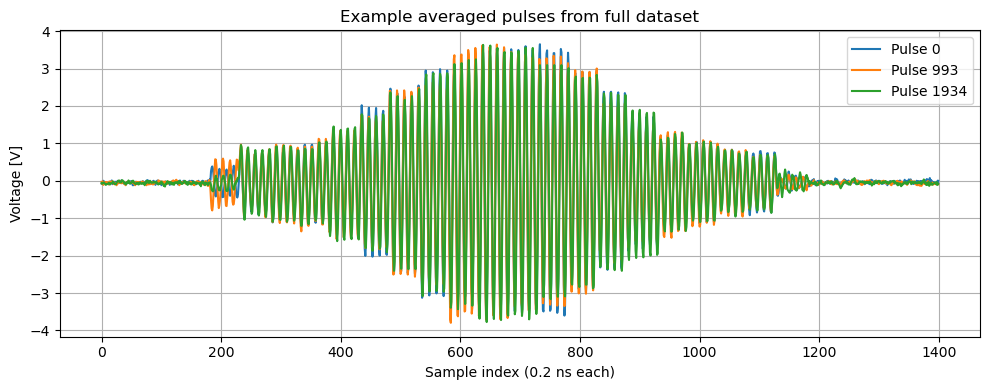

🟩 First positions > 0.1 V for valid pulses:
[183 183 230 184 183 183 197 230 189 183]


In [239]:
# --------- Visual sanity check ----------
plt.figure(figsize=(10, 4))
for k in [0, 993, 1934]:
    plt.plot(windows[k], label=f"Pulse {k}")
plt.xlabel(f"Sample index (0.2 ns each)")
plt.ylabel("Voltage [V]")
plt.title("Example averaged pulses from full dataset")
plt.grid(); plt.legend(); plt.tight_layout(); plt.show()
# windows.shape = (2000, N), por ejemplo (2000, 1400)

threshold = 0.1
first_above_threshold = np.argmax(windows > threshold, axis=1)  # shape: (2000,)

# Algunos pulsos pueden no superar el umbral: asegúrate
valid = (windows > threshold).any(axis=1)

print("🟩 First positions > 0.1 V for valid pulses:")
print(first_above_threshold[valid][:10])  # muestra los primeros 10



TARGET PULSE

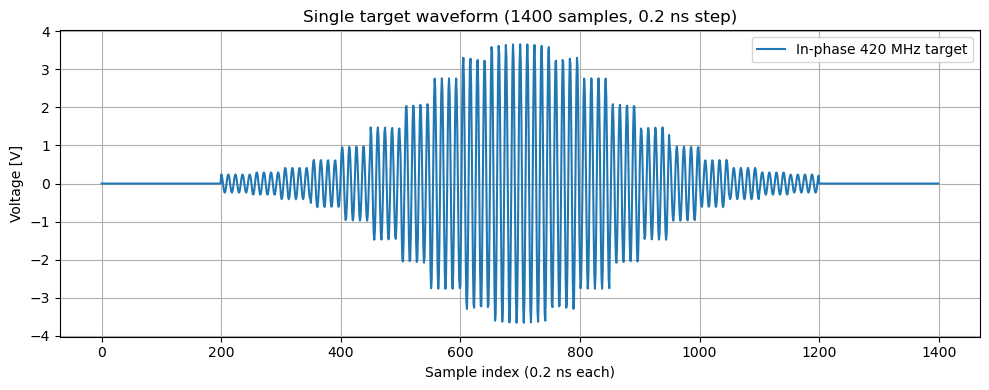

In [ ]:
# =========== Build a single in-phase 420-MHz TARGET pulse (adapted to 0.2 ns/sample) ===========
import numpy as np
import matplotlib.pyplot as plt

# -------- Parameters ----------
DT_NS              = 0.2                  # updated sampling interval
PRE_EDGE_SAMPLES   = 200                  # centered at sample 200
PULSE_SAMPLES      = 1000                 # 200 ns / 0.2 ns
WINDOW_SAMPLES     = 1400                 # total window
F_CARRIER_HZ       = 420e6
T_SAMPLE_SEC       = DT_NS * 1e-9
OMEGA              = 2 * np.pi * F_CARRIER_HZ
amp = 3.5

# -------- Define ideal envelope (Gaussian-like, 20 segments) ----------
segments = 20
x_gauss = np.linspace(-3, 3, segments)
envelope20 = 0.2 + amp * np.exp(-x_gauss**2 / 2)           # shape: (20,)
envelope1000 = np.repeat(envelope20, 50)                   # upsample to 1000 samples

# -------- Generate carrier and modulate ----------
t = np.arange(PULSE_SAMPLES) * T_SAMPLE_SEC
carrier = np.cos(OMEGA * t)
pulse_target = envelope1000 * carrier                      # shape: (1000,)

# -------- Embed in full 1400-sample window with padding --------
target_single = np.zeros(WINDOW_SAMPLES)
target_single[PRE_EDGE_SAMPLES : PRE_EDGE_SAMPLES + PULSE_SAMPLES] = pulse_target

# -------- Plot the single target pulse --------
plt.figure(figsize=(10, 4))
plt.plot(target_single, label="In-phase 420 MHz target")
plt.xlabel("Sample index (0.2 ns each)")
plt.ylabel("Voltage [V]")
plt.title("Single target waveform (1400 samples, 0.2 ns step)")
plt.grid(); plt.legend(); plt.tight_layout(); plt.show()

# Optional: replicate for 2000 samples
targets = np.tile(target_single, (2000, 1))  # shape = (2000, 1400)

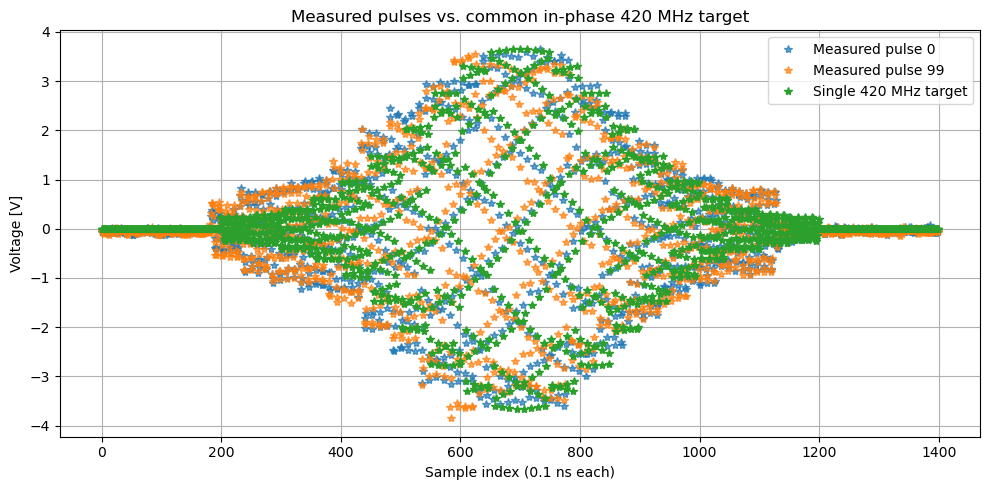

In [241]:
# ======= Overlay the ideal target with two measured pulses =======
idx1, idx2 = 0, 99  # pulses to plot from your real data

plt.figure(figsize=(10, 5))
plt.plot(windows[idx1], '*',label=f"Measured pulse {idx1}", alpha=0.7)
plt.plot(windows[idx2], '*', label=f"Measured pulse {idx2}", alpha=0.7)
plt.plot(target_single, '*', label="Single 420 MHz target", )# linestyle='--', linewidth=2)

plt.xlabel("Sample index (0.1 ns each)")
plt.ylabel("Voltage [V]")
plt.title("Measured pulses vs. common in-phase 420 MHz target")
plt.grid(); plt.legend(); plt.tight_layout(); plt.show()


AVERAGING TO HAVE A 20 SEGMENTS OUTPUT WAVE ENVELOPE AND 20 SEGMENTS TARGET ENVELOPE

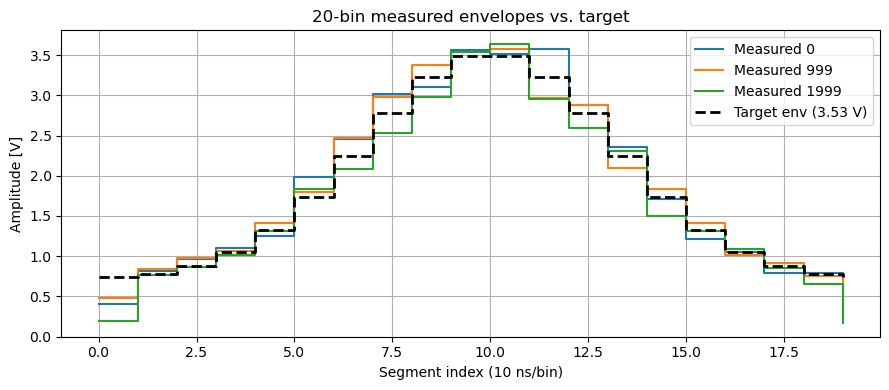

✅ Saved: dataset_envelopes_20_all.npz (X, Y, T)


In [249]:
# ================== Build 20-segment dataset (2000 pulses @ 0.2 ns) ==================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from gaussian_waveforms import waveforms as wf_list  # 2000 programmed input envelopes

# ---------- Constants ----------
SEGMENTS         = 20
PULSE_SAMPLES    = 1000                 # 200 ns at 0.2 ns/sample
BIN              = PULSE_SAMPLES // SEGMENTS  # 50 samples → 10 ns/bin
TARGET_PEAK_V    = 3.53

# ---------- 1. Extract measured envelopes ----------
pulses_only = windows[:, 183:PULSE_SAMPLES+183]
env_meas_full = np.abs(hilbert(pulses_only, axis=1))                             # (2000, 1000)

# ---------- 2. Downsample to 20 bins ----------
env_meas_20 = env_meas_full.reshape(-1, SEGMENTS, BIN).mean(axis=2)              # (2000, 20)

# ---------- 3. Build target envelope with edges = 0 V ----------
x = np.linspace(-3, 3, SEGMENTS)
env_base      = 0.2 + 0.8 * np.exp(-x**2 / 2)
target_env20  = TARGET_PEAK_V * env_base

# ---------- 4. Load programmed input waveforms ----------
X_inputs = np.asarray(wf_list[:2000], dtype=float)  # (2000, 20)

# ---------- 5. Visual sanity check ----------
plt.figure(figsize=(9, 4))
plt.step(range(SEGMENTS), env_meas_20[0],     where="post", label="Measured 0")
plt.step(range(SEGMENTS), env_meas_20[999],   where="post", label="Measured 999")
plt.step(range(SEGMENTS), env_meas_20[1999],  where="post", label="Measured 1999")
plt.step(range(SEGMENTS), target_env20,       where="post", linestyle="--", linewidth=2,
         color="black", label="Target env (3.53 V)")
plt.xlabel("Segment index (10 ns/bin)")
plt.ylabel("Amplitude [V]")
plt.title("20-bin measured envelopes vs. target")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

# ---------- 6. Save dataset ----------
np.savez(
    "dataset_envelopes_20_all.npz",
    X=X_inputs,       # (2000, 20)
    Y=env_meas_20,    # (2000, 20)
    T=target_env20    # (20,)
)
print("✅ Saved: dataset_envelopes_20_all.npz (X, Y, T)")


In [250]:
# ================== Load waveform chunks in numerical order and save dataset ==================
import numpy as np
import importlib.util
from pathlib import Path
from sklearn.model_selection import train_test_split

# -------- Folder with the waveform chunks --------
chunk_folder = Path("waveform_chunks")

# -------- Custom sort function to ensure numerical order --------
def extract_start_index(path):
    # e.g. waveforms_000_199 → 0
    return int(path.stem.split("_")[1])

# -------- Get sorted chunk files --------
chunk_files = sorted(chunk_folder.glob("waveforms_*.py"), key=extract_start_index)
N_amp_out=SEGMENTS
# -------- Load waveforms from each chunk --------
X_list = []
for path in chunk_files:
    spec = importlib.util.spec_from_file_location(path.stem, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    if not hasattr(mod, "waveforms"):
        raise AttributeError(f"❌ No 'waveforms' list in: {path.name}")
    wf = mod.waveforms
    if len(wf) != 200:
        raise ValueError(f"❌ Expected 200 waveforms in {path.name}, got {len(wf)}")
    X_list.extend(wf)
    print(f"✅ Loaded {path.name:25s} with {len(wf)} waveforms")

# -------- Stack into final X_inputs array --------
X_inputs = np.asarray(X_list, dtype=float)
print(f"\n📦 Final shape of X_inputs: {X_inputs.shape}")  # (2000, 20)

# -------- Load matching outputs --------
data = np.load("dataset_envelopes_20_all.npz")
Y_outputs = data["Y"]
target    = data["T"]

# -------- Ensure matching shape --------
#assert X_inputs.shape == Y_outputs.shape == (2000, N_amp_out), "❌ X and Y shapes must match!"

# -------- Split into training and test sets --------
X_train, X_test, Y_train, Y_test = train_test_split(
    X_inputs, Y_outputs, test_size=0.2, random_state=42, shuffle=True
)
x = np.linspace(-3, 3, N_amp_out)

target_env20 = 3.53 * (0.2 + (1.0 - 0.2) * np.exp(-x**2 / 2))  # (20,)
# -------- Save final dataset --------
np.savez("dataset_envelopes_20_split.npz",
         X_train=X_train, Y_train=Y_train,
         X_test=X_test,   Y_test=Y_test,
         target=target_env20)

print("\n💾 Saved: dataset_envelopes_20_split.npz")
print(f"   X_train: {X_train.shape}   Y_train: {Y_train.shape}")
print(f"   X_test : {X_test.shape}   Y_test : {Y_test.shape}")



✅ Loaded waveforms_000_199.py      with 200 waveforms
✅ Loaded waveforms_200_399.py      with 200 waveforms
✅ Loaded waveforms_400_599.py      with 200 waveforms
✅ Loaded waveforms_600_799.py      with 200 waveforms
✅ Loaded waveforms_800_999.py      with 200 waveforms
✅ Loaded waveforms_1000_1199.py    with 200 waveforms
✅ Loaded waveforms_1200_1399.py    with 200 waveforms
✅ Loaded waveforms_1400_1599.py    with 200 waveforms
✅ Loaded waveforms_1600_1799.py    with 200 waveforms
✅ Loaded waveforms_1800_1999.py    with 200 waveforms

📦 Final shape of X_inputs: (2000, 20)

💾 Saved: dataset_envelopes_20_split.npz
   X_train: (1600, 20)   Y_train: (1600, 20)
   X_test : (400, 20)   Y_test : (400, 20)


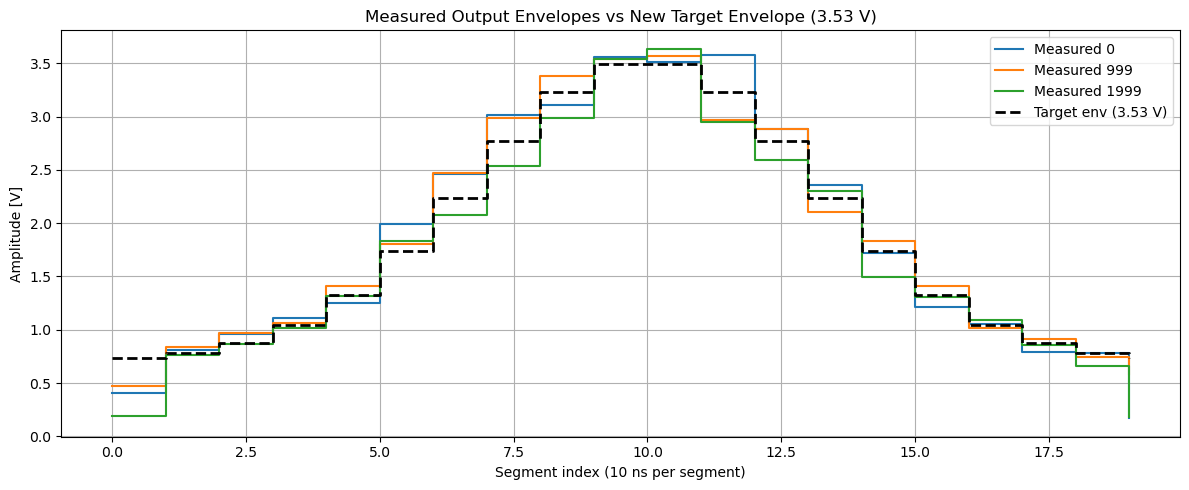

In [251]:
# -------------------- Target envelope (20 pts, pico 3.53 V) --------------------
SEGMENTS      = N_amp_out
TARGET_PEAK_V = 3.53

x         = np.linspace(-3, 3, SEGMENTS)                      # mismo eje que en los inputs
gauss_raw = np.exp(-x**2 / 2)                                 # N(0,1) evaluada
base_env  = 0.2 + 0.8 * gauss_raw                             # 0.2 → 1.0 (idéntico al script)
target_env20 = TARGET_PEAK_V * base_env                       # escala a 3.53 V

# (opcional) guardar para que todo tu pipeline lo cargue luego
np.savez("target_env20.npz", target=target_env20)

# -------------------- Plot comparación rápida --------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

ids_to_plot = [0, 999, 1999]           # tres índices de Y_outputs
colors      = ["C0", "C1", "C2"]

for cid, idx in enumerate(ids_to_plot):
    plt.step(range(SEGMENTS),
             Y_outputs[idx],           # envelope medido
             where="post",
             label=f"Measured {idx}",
             color=colors[cid])

plt.step(range(SEGMENTS),
         target_env20,
         where="post",
         ls="--",
         lw=2,
         color="k",
         label="Target env (3.53 V)")

plt.xlabel("Segment index (10 ns per segment)")
plt.ylabel("Amplitude [V]")
plt.title("Measured Output Envelopes vs New Target Envelope (3.53 V)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


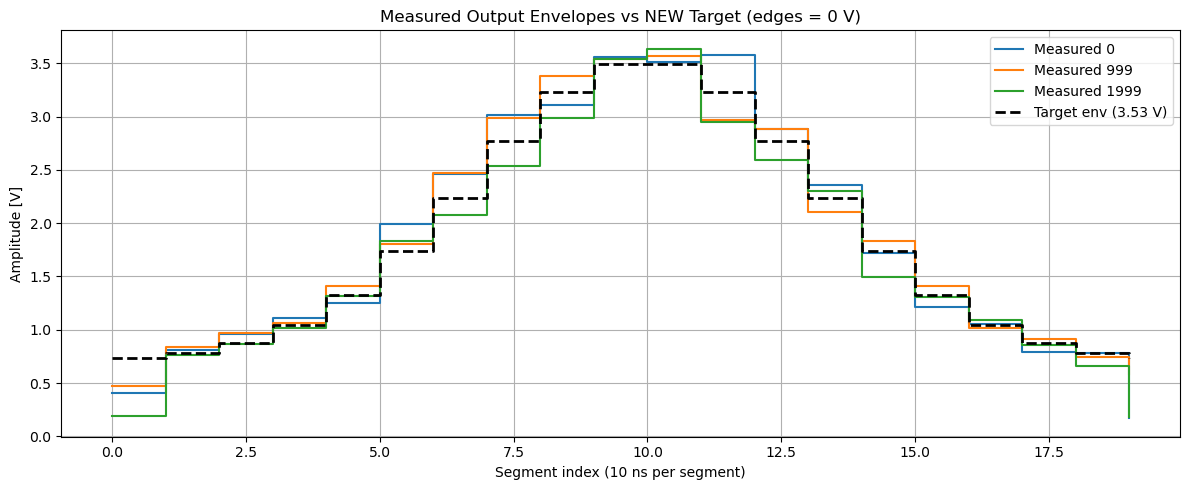

In [252]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Parámetros ----------
SEGMENTS      = N_amp_out
TARGET_PEAK_V = 3.53

# ---------- Reconstruir la gaussiana base (idéntica al generador) ----------
x         = np.linspace(-3, 3, SEGMENTS)
gauss_raw = np.exp(-x**2 / 2)
base_env  = 0.2 + 0.8 * gauss_raw      # 0.2 → 1.0

# ---------- Escalado a 3.53 V ----------
target_env20 = TARGET_PEAK_V * base_env

# ---------- Forzar bordes a 0 V ----------
#target_env20[0]  = 0.5
#target_env20[-1] = 0.5

# ---------- Guardar (opcional) ----------
np.savez("target_env20.npz", target=target_env20)

# ---------- Visualizar junto a 3 envelopes medidos ----------
ids_to_plot = [0, 999, 1999]
colors      = ["C0", "C1", "C2"]

plt.figure(figsize=(12, 5))
for c, idx in zip(colors, ids_to_plot):
    plt.step(range(SEGMENTS), Y_outputs[idx], where="post",
             label=f"Measured {idx}", color=c)

plt.step(range(SEGMENTS), target_env20, where="post",
         ls="--", lw=2, color="k", label="Target env (3.53 V)")

plt.xlabel("Segment index (10 ns per segment)")
plt.ylabel("Amplitude [V]")
plt.title("Measured Output Envelopes vs NEW Target (edges = 0 V)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


MACHINE LEARNING

Firstly, I use a train+test approach to see how the model fits the truth.
Secondly, I use all the data as training data to train the model and predict the best input wave.

In [253]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# -------- Load pre-split dataset --------
data = np.load("dataset_envelopes_20_split.npz")

X_train = data["X_train"]   # (1600, 20)
Y_train = data["Y_train"]   # (1600, 20)
X_test  = data["X_test"]    # (400, 20)
Y_test  = data["Y_test"]    # (400, 20)
target_env20  = data["target"]    # (20,)

# -------- Build pipeline: normalize + MLP regressor --------
model = make_pipeline(
    StandardScaler(),                             # normalize input
    MLPRegressor(hidden_layer_sizes=(64, 64),     # two hidden layers of 64 neurons
                 activation="relu",
                 max_iter=3000,
                 random_state=0)
)

# -------- Train the model --------
model.fit(X_train, Y_train)
print("✅ Model training complete!")

# -------- Evaluate on test set --------
Y_pred = model.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred)
print(f"📉 Test MSE: {mse:.6f}")



✅ Model training complete!
📉 Test MSE: 0.013772


📊 Test MSE: 0.013772


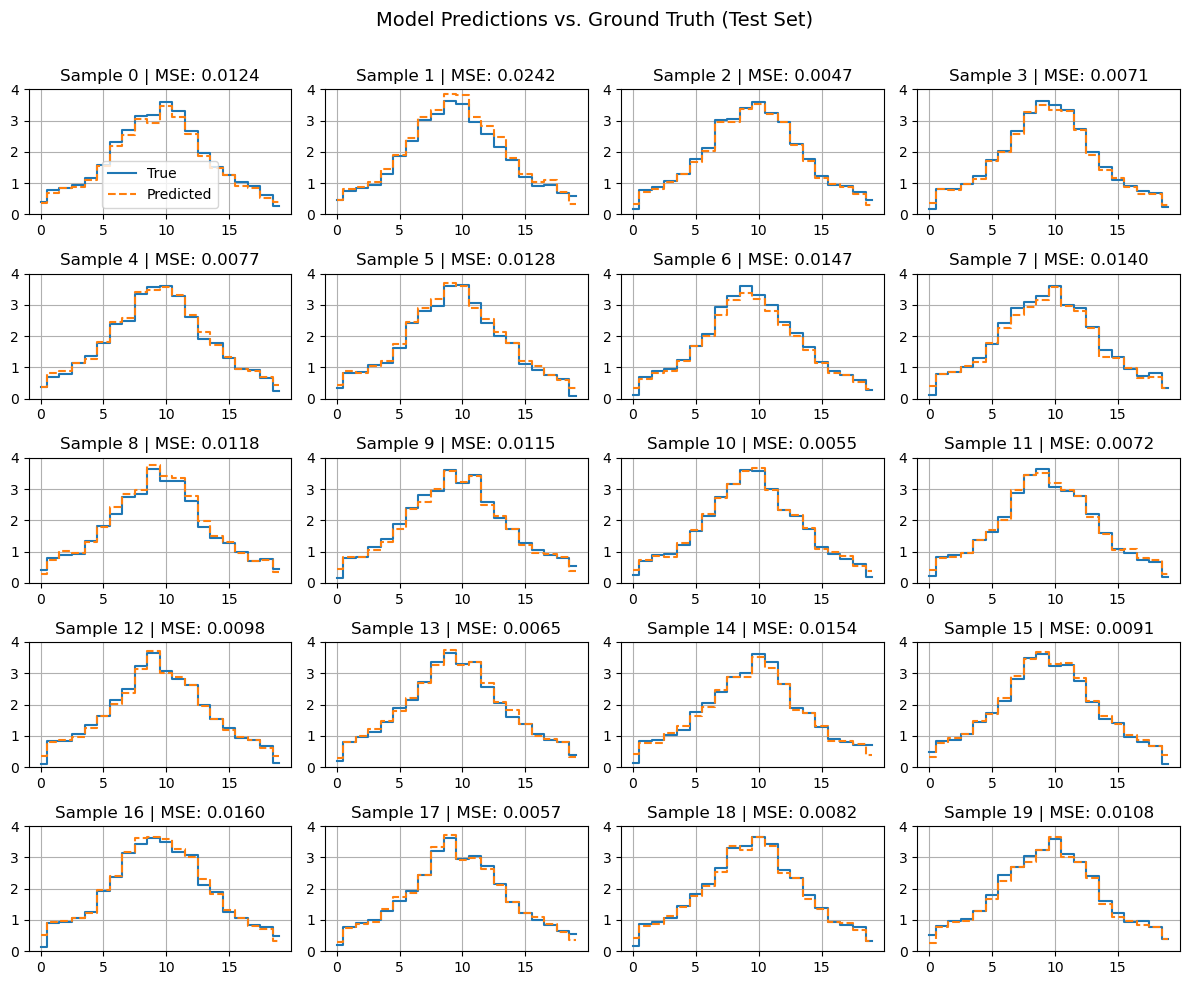

In [254]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# -------- Predict on test set --------
Y_pred_test = model.predict(X_test)
mse_test = mean_squared_error(Y_test, Y_pred_test)

print("📊 Test MSE:", round(mse_test, 6))

# -------- Plot a selection of test envelopes --------
NUM_PLOTS = 20
indices = np.arange(NUM_PLOTS)  # or use np.random.choice(len(Y_test), NUM_PLOTS, replace=False)

plt.figure(figsize=(12, 10))
for i, idx in enumerate(indices):
    plt.subplot(5, 4, i + 1)
    plt.step(range(SEGMENTS), Y_test[idx], label="True", where="mid")
    plt.step(range(SEGMENTS), Y_pred_test[idx], label="Predicted", where="mid", linestyle='--')
    plt.title(f"Sample {idx} | MSE: {np.mean((Y_test[idx] - Y_pred_test[idx])**2):.4f}")
    plt.ylim(0, 4.0)
    plt.grid(True)
    if i == 0:
        plt.legend()
plt.suptitle("Model Predictions vs. Ground Truth (Test Set)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


🧪 Test with 400 training samples → MSE: 0.05533
🧪 Test with 500 training samples → MSE: 0.04075
🧪 Test with 600 training samples → MSE: 0.03716
🧪 Test with 700 training samples → MSE: 0.03749
🧪 Test with 800 training samples → MSE: 0.02630
🧪 Test with 900 training samples → MSE: 0.02458
🧪 Test with 1000 training samples → MSE: 0.02353
🧪 Test with 1100 training samples → MSE: 0.01882
🧪 Test with 1200 training samples → MSE: 0.01674
🧪 Test with 1300 training samples → MSE: 0.01668
🧪 Test with 1400 training samples → MSE: 0.01780
🧪 Test with 1500 training samples → MSE: 0.01314
🧪 Test with 1600 training samples → MSE: 0.01320
🧪 Test with 1700 training samples → MSE: 0.00994
🧪 Test with 1800 training samples → MSE: 0.01239
🧪 Test with 1900 training samples → MSE: 0.01046


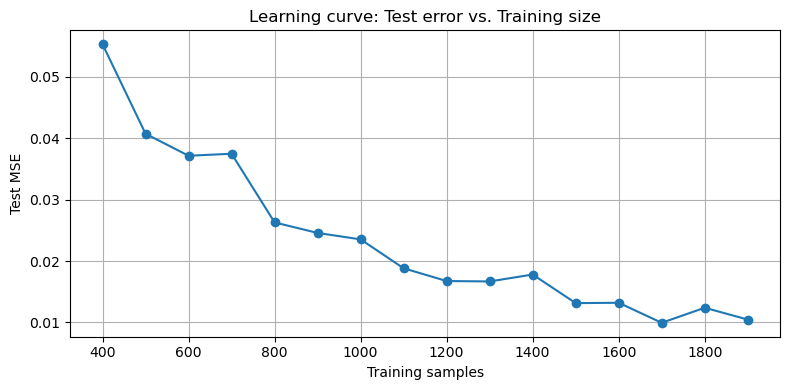

In [255]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# ---- Load full dataset (2000 samples) ----
data = np.load("dataset_envelopes_20_split.npz")
X_all = np.vstack([data["X_train"], data["X_test"]])   # (2000, 20)
Y_all = np.vstack([data["Y_train"], data["Y_test"]])   # (2000, 20)
target_env20 = data["target"]                                # (20,)

# ---- Shuffle dataset once ----
X_all, Y_all = shuffle(X_all, Y_all, random_state=42)

# ---- Initialize training ----
block_size = 100
total_samples = X_all.shape[0]
initial_train_num = 400

train_X = X_all[:initial_train_num]
train_Y = Y_all[:initial_train_num]

errors = []
steps = []

# ---- Incremental training loop ----
for i in range(initial_train_num, total_samples, block_size):
    test_X = X_all[i:i+block_size]
    test_Y = Y_all[i:i+block_size]

    # Train model on current training set
    model = make_pipeline(
        StandardScaler(),
        MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=3000, random_state=0)
    )
    model.fit(train_X, train_Y)

    # Evaluate on test block
    pred_Y = model.predict(test_X)
    mse = mean_squared_error(test_Y, pred_Y)
    errors.append(mse)
    steps.append(len(train_X))
    print(f"🧪 Test with {len(train_X)} training samples → MSE: {mse:.5f}")

    # Expand training set
    train_X = np.vstack([train_X, test_X])
    train_Y = np.vstack([train_Y, test_Y])

# ---- Plot learning curve ----
plt.figure(figsize=(8, 4))
plt.plot(steps, errors, marker="o")
plt.xlabel("Training samples")
plt.ylabel("Test MSE")
plt.title("Learning curve: Test error vs. Training size")
plt.grid(True)
plt.tight_layout()
plt.show()




🔍 Optimizing with: MSE
✅ Final loss for MSE: 0.00117

🔍 Optimizing with: MAE
✅ Final loss for MAE: 0.10703

🔍 Optimizing with: Huber
✅ Final loss for Huber: 0.00235

🔍 Optimizing with: Weighted MSE
✅ Final loss for Weighted MSE: 0.00434


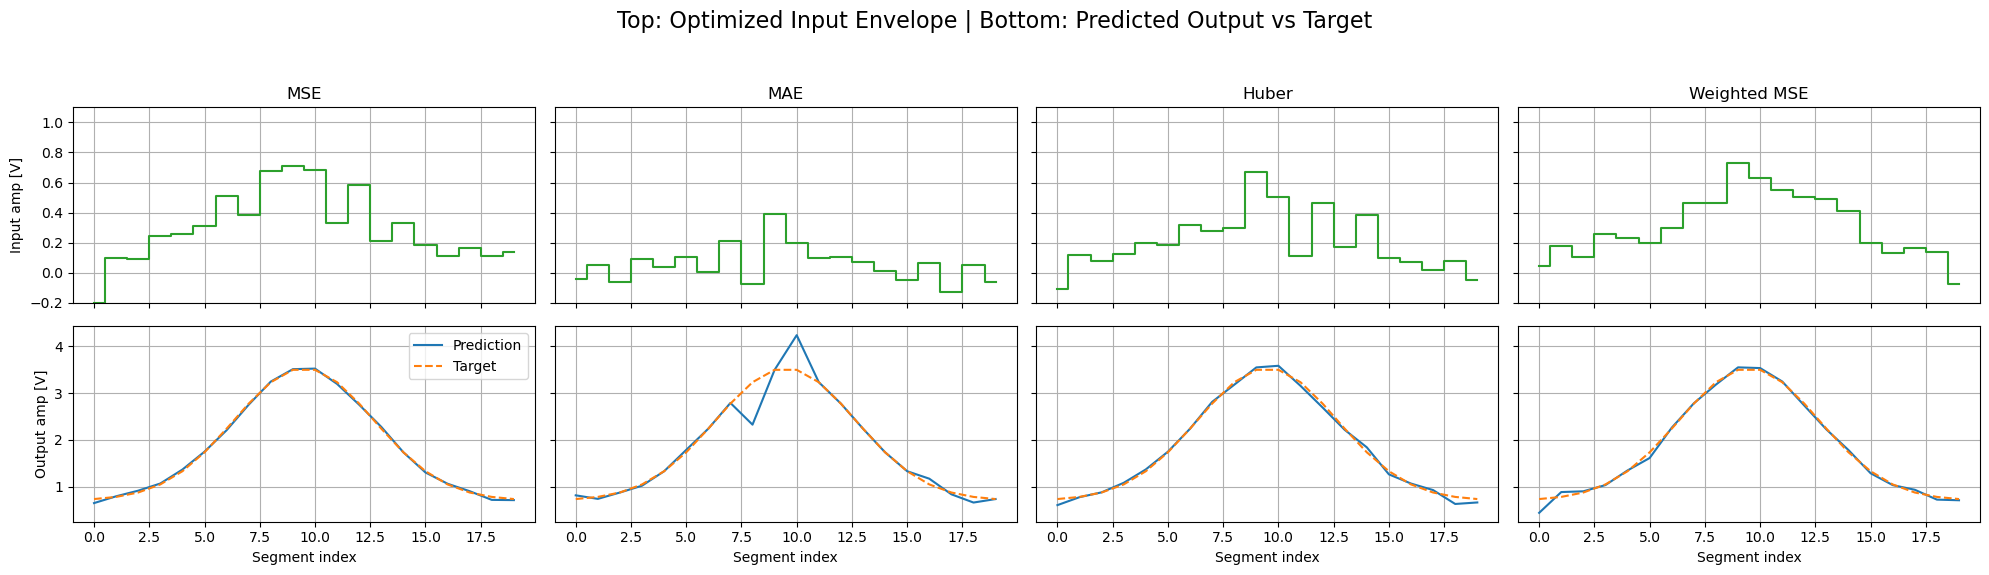

In [256]:
from scipy.optimize import minimize 
import matplotlib.pyplot as plt
import numpy as np

# ✅ Usa el target cargado desde el .npz
# target_env20 = data["target"]
target = target_env20  # para consistencia si ya cargaste como 'target'

# ---- Loss functions ----
def loss_mse(x):
    y_pred = model.predict(x.reshape(1, -1))[0]
    return np.mean((y_pred - target)**2)

def loss_mae(x):
    y_pred = model.predict(x.reshape(1, -1))[0]
    return np.mean(np.abs(y_pred - target))

def loss_huber(x, delta=0.2):
    y_pred = model.predict(x.reshape(1, -1))[0]
    diff = y_pred - target
    mask = np.abs(diff) <= delta
    quad = 0.5 * diff[mask]**2
    lin  = delta * (np.abs(diff[~mask]) - 0.5 * delta)
    return np.mean(np.concatenate([quad, lin]))

weights = np.linspace(0.5, 1.5, SEGMENTS)
def loss_weighted_mse(x):
    y_pred = model.predict(x.reshape(1, -1))[0]
    return np.mean(weights * (y_pred - target)**2)

# ---- Loss function dictionary ----
loss_functions = {
    "MSE": loss_mse,
    "MAE": loss_mae,
    "Huber": lambda x: loss_huber(x, delta=0.2),
    "Weighted MSE": loss_weighted_mse
}

# ---- Optimization ----
x0 = np.zeros(20)
results_dict = {}      # optimized inputs
predictions_dict = {}  # model predictions

for name, loss_fn in loss_functions.items():
    print(f"\n🔍 Optimizing with: {name}")
    res = minimize(loss_fn, x0, method="L-BFGS-B", bounds=[(-1, 1)] * 20)
    print(f"✅ Final loss for {name}: {res.fun:.5f}")
    pulse = res.x
    results_dict[name] = pulse
    predictions_dict[name] = model.predict(pulse.reshape(1, -1))[0]

# ---- Plot input envelope + prediction for each method ----
fig, axs = plt.subplots(2, 4, figsize=(20, 6), sharex=True, sharey="row")

for i, name in enumerate(loss_functions.keys()):
    # Top row: input envelope
    axs[0, i].step(range(20), results_dict[name], where="mid", color="C2")
    axs[0, i].set_title(f"{name}")
    axs[0, i].set_ylim(-.2, 1.1)
    axs[0, i].grid(True)
    if i == 0:
        axs[0, i].set_ylabel("Input amp [V]")
    
    # Bottom row: predicted vs target
    axs[1, i].plot(predictions_dict[name], label="Prediction", color="C0")
    axs[1, i].plot(target, label="Target", linestyle="--", color="C1")
    axs[1, i].grid(True)
    if i == 0:
        axs[1, i].set_ylabel("Output amp [V]")
    axs[1, i].set_xlabel("Segment index")

axs[1, 0].legend()
plt.suptitle("Top: Optimized Input Envelope | Bottom: Predicted Output vs Target", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.94])
plt.show()


✅ Surrogate trained | MSE on full dataset: 0.006348

🔧 Optimised input envelope:
[-0.325  0.027 -0.006  0.176  0.13   0.163  0.093  0.506  0.412  0.508
  0.227  0.206  0.143  0.136  0.09   0.14   0.154  0.003  0.113 -0.097]


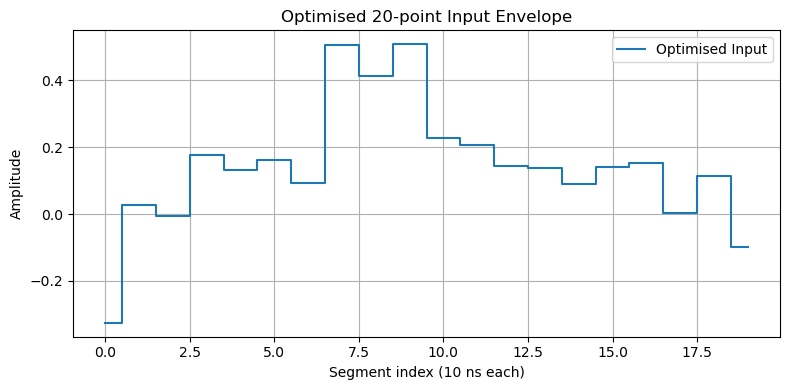

In [257]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

# -------- 1) Load full dataset --------
data = np.load("dataset_envelopes_20_split.npz")
X_inputs = np.vstack([data["X_train"], data["X_test"]])   # (2000, 20)
Y_outputs = np.vstack([data["Y_train"], data["Y_test"]])  # (2000, 20)
target_env20 = data["target"]                                   # (20,)

# -------- 2) Train full surrogate model --------
model_full = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(64, 64),
                 activation="relu",
                 max_iter=15000,
                 random_state=0)
)

model_full.fit(X_inputs, Y_outputs)
mse_train = mean_squared_error(Y_outputs, model_full.predict(X_inputs))
print(f"✅ Surrogate trained | MSE on full dataset: {mse_train:.6f}")

# -------- 3) Define loss to optimize --------
def loss_fn(x):
    y_pred = model_full.predict(x.reshape(1, -1))[0]
    return np.mean((y_pred - target_env20)**2)   # MSE loss to target envelope

# -------- 4) Run optimization --------
x0 = np.zeros(20)  # or use np.mean(X_inputs, axis=0)
res = minimize(loss_fn, x0, method="L-BFGS-B", bounds=[(-1, 1)]*20)

best_pulse = res.x
print("\n🔧 Optimised input envelope:")
print(np.round(best_pulse, 3))

# -------- 5) Plot optimised envelope --------
plt.figure(figsize=(8, 4))
plt.step(range(20), best_pulse, where="mid", label="Optimised Input")
plt.title("Optimised 20-point Input Envelope")
plt.xlabel("Segment index (10 ns each)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
